# 02 — Baseline classifier: LMC vs Milky Way

Notebook 01 showed the physics is visible: the LMC holds a tight, shared proper motion that
the foreground does not. Now we train a model to do the separation, and measure it on stars
it has never seen.

**Model:** XGBoost — gradient-boosted trees. The standard strong baseline for tabular data:
it handles non-linear interactions between features, needs no scaling, and reports which
features drove its decisions.

### The one design decision that matters: no sky position

Notebook 01 ended on a warning. The LMC is a concentrated clump on the sky, so a model given
`ra`/`dec` can memorise *"this box = LMC"* and score beautifully while learning no physics —
contaminating the catalogue with every foreground star that shares the patch, and transferring
to no other pointing.

We exclude position — and in section 8 we **train the cheating model anyway**, to show
concretely what it buys and what it costs. Asserting the decision is easy; demonstrating it
is the point.

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score)

import lmc
from lmc.split import SEED, TEST_SIZE, make_split, save_split

# Versioned, because this is not the last model this project trains. Notebook 05
# builds a second one, and the story needs both on disk at the same time.
OUT = Path("../outputs/v1_baseline"); OUT.mkdir(parents=True, exist_ok=True)

df = lmc.load_sim(verbose=True)

  loaded 1,269,704 rows from data/processed/train_clean.parquet


## 0. The data-quality catch, again

Notebook 01 found it the hard way: one corrupted `pmra` value (`"1.8598455n11059828"`) types
the whole column as text, and every calculation downstream silently does the wrong thing.

That repair now lives in `lmc.io.clean_sim()` and runs once, in `scripts/build_cache.py`,
which writes `data/processed/train_clean.parquet`. Five notebooks and two export scripts read
that file. The point is not the 15 seconds saved per load — it is that there is now exactly
**one** definition of "clean", so the numbers in this notebook and the numbers on the website
cannot drift apart.

A cache you cannot trace is worse than no cache, so the builder also records what it was made
from. Print the fingerprint rather than assuming.

In [2]:
fp = lmc.fingerprint()
print(f"built from    {fp['source']}")
print(f"sha256        {fp['source_sha256'][:32]}...")
print(f"raw rows      {fp['rows_raw']:,}")
print(f"dropped       {fp['rows_dropped']}   <- the corrupted pmra row")
print(f"clean rows    {fp['rows_clean']:,}")

# Assert rather than eyeball: if the cache is stale relative to this run, stop here.
assert df.height == fp["rows_clean"], "cache is stale — rerun scripts/build_cache.py --force"
assert df.null_count().to_numpy().sum() == 0, "nulls survived the clean"
print(f"\ndtypes: {sorted({str(d) for d in df.dtypes})}")
print("no nulls anywhere — and that clean bill of health is earned, not assumed.")

built from    LMC+MW_GOG_trainingset_frac=0.2.csv
sha256        226a8fd3d586ddd01f2de225f1cb737c...
raw rows      1,269,705
dropped       1   <- the corrupted pmra row
clean rows    1,269,704

dtypes: ['Float64', 'Int64']
no nulls anywhere — and that clean bill of health is earned, not assumed.


## 1. Features

Eleven inputs: the raw measurements, plus two derived from them by `lmc.features.add_derived()`
(already present in the cached frame).

- **`pm_total`** = √(pmra² + pmdec²) — total proper-motion magnitude. The trees can only cut
  on one feature at a time, so a quantity that needs both axes at once is worth handing over
  ready-made.
- **`bp_rp`** = BP − RP — colour, a temperature proxy.

We also keep the measurement **errors**. How well a star was measured is itself informative:
LMC members are faint and distant, so their uncertainties run systematically larger. That is
a real, physical correlate of membership, not a leak.

> ⚠️ **That last paragraph is wrong, and notebook 04 proves it.** It is left exactly as first
> written because it is the reasonable belief a careful person holds at this point — the
> errors *are* correlated with membership, and within this simulation that correlation is
> real. What it misses is that the correlation is an artifact of *how faint the simulated LMC
> is*, not of what an LMC star is, so it inverts the moment the model meets real, bright
> Cepheids. Those three columns cost 74 points of real-sky recall. Keep reading.

In [3]:
FEATURES = lmc.FEATURE_SETS["v1"]   # defined once, in src/lmc/features.py
EXCLUDED = ["ra", "dec"]

X = df.select(FEATURES).to_numpy()
y = df["Type"].to_numpy()          # 1 = LMC, 0 = Milky Way

print(f"{len(FEATURES)} features in, {len(EXCLUDED)} deliberately left out ({', '.join(EXCLUDED)})")
print(f"X = {X.shape}    LMC positives = {int(y.sum()):,} ({100*y.mean():.2f}%)\n")
for f in FEATURES:
    print(f"  {f}")

11 features in, 2 deliberately left out (ra, dec)
X = (1269704, 11)    LMC positives = 277,177 (21.83%)

  pmra
  pmdec
  pm_total
  parallax
  pmra_error
  pmdec_error
  parallax_error
  phot_g_mean_mag
  phot_bp_mean_mag
  phot_rp_mean_mag
  bp_rp


## 2. Train / test split

Stratified 80/20. `stratify=y` holds the same 78/22 balance in both halves so the test score
is a fair estimate rather than an accident of sampling.

**We split indices, not arrays, and we save them with a hash of the labels.** The web
visualiser has to draw the held-out stars specifically — "where the model is wrong" is only an
honest claim if it shows test-set errors.

The export scripts used to *re-derive* this split by calling `train_test_split` again with the
same seed. That reproduces the same rows only while the row count **and** the label ordering
are byte-identical to what this notebook saw. Change the cleaning step — decide differently
about one null column — and the app's "held-out" overlay quietly becomes an arbitrary subset
while every number on screen still looks plausible. `lmc.split.save_split()` stores a SHA-256
of `y` alongside the indices, and loading verifies it, so that failure becomes a stack trace
instead of a plausible lie.

In [4]:
train_idx, test_idx = make_split(y)      # stratified on y, seed 42

X_tr, X_te = X[train_idx], X[test_idx]
y_tr, y_te = y[train_idx], y[test_idx]

print(f"train: {len(train_idx):,}   test: {len(test_idx):,}")
print(f"LMC fraction — train {y_tr.mean():.4f}   test {y_te.mean():.4f}   (stratified, so equal)")
print(f"overlap between train and test: {len(np.intersect1d(train_idx, test_idx))} rows")

train: 1,015,763   test: 253,941
LMC fraction — train 0.2183   test 0.2183   (stratified, so equal)
overlap between train and test: 0 rows


## 3. The class imbalance

The Milky Way outnumbers the LMC 3.58 : 1. Untouched, a model can score 78% accuracy by
leaning toward "Milky Way" and catching nothing. XGBoost's `scale_pos_weight` re-weights the
rare positive class by exactly that ratio — telling the model an LMC star is 3.58× as costly
to miss.

In [5]:
neg, pos = int((y_tr == 0).sum()), int((y_tr == 1).sum())
spw = neg / pos
print(f"Milky Way (neg): {neg:,}   LMC (pos): {pos:,}")
print(f"scale_pos_weight = {spw:.4f}")

Milky Way (neg): 794,021   LMC (pos): 221,742
scale_pos_weight = 3.5808


## 4. Train

In [6]:
clf = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=spw,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=SEED,
)
clf.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
print("trained.")

trained.


## 5. Evaluate on the held-out split

Accuracy is not the metric here — 78% is free. The two numbers that describe a membership
catalogue are:

- **Recall (LMC)** — of the real LMC stars, how many did we keep? Low recall means we threw
  away real members.
- **Precision (LMC)** — of the stars we called LMC, how many really are? Low precision means
  the catalogue is contaminated with foreground.

**PR-AUC** is the honest threshold-independent summary under imbalance; ROC-AUC flatters
imbalanced problems because the huge true-negative pool inflates it.

In [7]:
y_prob = clf.predict_proba(X_te)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_te, y_pred, target_names=["Milky Way (0)", "LMC (1)"], digits=4))
roc = roc_auc_score(y_te, y_prob)
pr = average_precision_score(y_te, y_prob)
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC : {pr:.4f}")

               precision    recall  f1-score   support

Milky Way (0)     0.9988    0.9944    0.9966    198506
      LMC (1)     0.9804    0.9958    0.9880     55435

     accuracy                         0.9947    253941
    macro avg     0.9896    0.9951    0.9923    253941
 weighted avg     0.9948    0.9947    0.9947    253941

ROC-AUC: 0.9998
PR-AUC : 0.9992


## 6. Confusion matrix

Rows are truth, columns are prediction. Both off-diagonal cells have a physical meaning worth
naming: one is members lost, the other is foreground smuggled in.

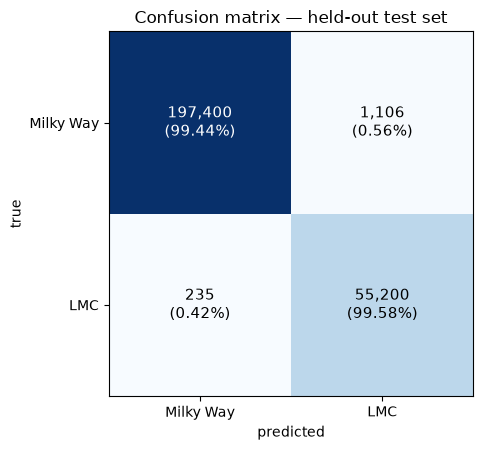

LMC members kept (recall):        55,200 / 55,435  = 99.58%
LMC members lost:                 235
foreground wrongly called LMC:    1,106 / 198,506  = 0.56%
resulting catalogue purity:       98.04%


In [8]:
cm = confusion_matrix(y_te, y_pred)
labels = ["Milky Way", "LMC"]

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels); ax.set_yticks([0, 1], labels)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion matrix — held-out test set")
for i in range(2):
    row = cm[i].sum()
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}\n({100*cm[i,j]/row:.2f}%)", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=11)
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"LMC members kept (recall):        {tp:,} / {tp+fn:,}  = {100*tp/(tp+fn):.2f}%")
print(f"LMC members lost:                 {fn:,}")
print(f"foreground wrongly called LMC:    {fp:,} / {fp+tn:,}  = {100*fp/(fp+tn):.2f}%")
print(f"resulting catalogue purity:       {100*tp/(tp+fp):.2f}%")

## 7. What the model learned

If notebook 01 was right, motion should dominate and parallax should barely register.

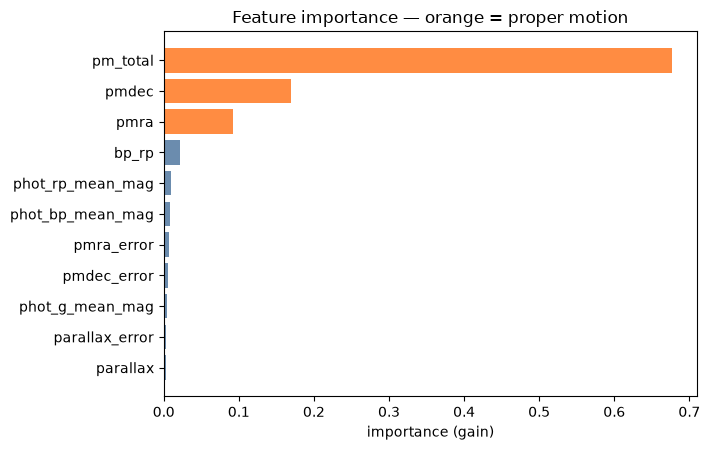

proper motion accounts for 93.7% of total importance
parallax accounts for      0.3%

  pm_total             0.6763
  pmdec                0.1690
  pmra                 0.0918
  bp_rp                0.0211
  phot_rp_mean_mag     0.0103
  phot_bp_mean_mag     0.0089
  pmra_error           0.0065
  pmdec_error          0.0059
  phot_g_mean_mag      0.0039
  parallax_error       0.0033
  parallax             0.0031


In [9]:
imp = clf.feature_importances_
order = np.argsort(imp)[::-1]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
colours = ["#ff8c42" if f in ("pmra", "pmdec", "pm_total") else "#6b8cae"
           for f in [FEATURES[i] for i in order][::-1]]
ax.barh([FEATURES[i] for i in order][::-1], imp[order][::-1], color=colours)
ax.set_xlabel("importance (gain)")
ax.set_title("Feature importance — orange = proper motion")
plt.tight_layout(); plt.show()

motion = sum(imp[FEATURES.index(f)] for f in ("pmra", "pmdec", "pm_total"))
print(f"proper motion accounts for {100*motion:.1f}% of total importance")
print(f"parallax accounts for      {100*imp[FEATURES.index('parallax')]:.1f}%\n")
for i in order:
    print(f"  {FEATURES[i]:<20} {imp[i]:.4f}")

Exactly the shape notebook 01 predicted: proper motion carries the decision, parallax is
almost worthless because at 50 kpc the measurement is noise. The model found the same physics
we found by eye — which is the check that it learned something real, not an artefact.

## 8. The control: what sky position would have bought us

Now the experiment behind the design decision. We train a second model on **`ra` and `dec`
alone** — no motion, no colour, no distance. It knows nothing about any star except where it
sits on the sky.

If position were harmless, this model should be near useless.

In [10]:
X_pos = df.select(["ra", "dec"]).to_numpy()
cheat = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9, scale_pos_weight=spw,
    eval_metric="logloss", tree_method="hist", n_jobs=-1, random_state=SEED,
)
cheat.fit(X_pos[train_idx], y_tr, verbose=False)

p_cheat = cheat.predict_proba(X_pos[test_idx])[:, 1]
cheat_pred = (p_cheat >= 0.5).astype(int)
cm_c = confusion_matrix(y_te, cheat_pred)
tn_c, fp_c, fn_c, tp_c = cm_c.ravel()

print("position-only model (ra, dec — nothing else):")
print(f"  ROC-AUC:     {roc_auc_score(y_te, p_cheat):.4f}   (physics model: {roc:.4f})")
print(f"  PR-AUC:      {average_precision_score(y_te, p_cheat):.4f}   (physics model: {pr:.4f})")
print(f"  LMC recall:  {100*tp_c/(tp_c+fn_c):.2f}%")
print(f"  purity:      {100*tp_c/(tp_c+fp_c):.2f}%")

position-only model (ra, dec — nothing else):
  ROC-AUC:     0.9790   (physics model: 0.9998)
  PR-AUC:      0.8898   (physics model: 0.9992)
  LMC recall:  99.60%
  purity:      79.63%


**Read those two lines carefully, because the trap is in the gap between them.**

Recall is 99.6% — indistinguishable from the physics model. On that number alone the shortcut
looks free. Purity is where it falls apart: 79.6% against 98.0%. The position model keeps
essentially every real member and hauls in a fifth of the field's foreground along with them.

Now look at what it actually learned:

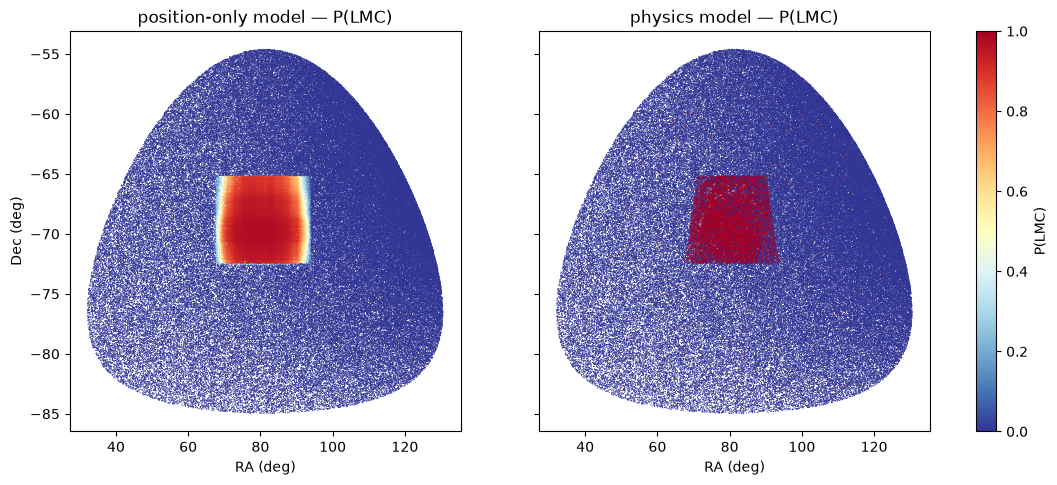

In [11]:
ra_all, dec_all = df["ra"].to_numpy(), df["dec"].to_numpy()
ra_te, dec_te = ra_all[test_idx], dec_all[test_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True, sharey=True)
for ax, (vals, title) in zip(axes, (
    (p_cheat, "position-only model — P(LMC)"),
    (y_prob,  "physics model — P(LMC)"),
)):
    sc = ax.scatter(ra_te, dec_te, c=vals, s=0.6, cmap="RdYlBu_r", vmin=0, vmax=1, lw=0)
    ax.set_title(title); ax.set_xlabel("RA (deg)")
    ax.invert_xaxis()
axes[0].set_ylabel("Dec (deg)")
fig.colorbar(sc, ax=axes, label="P(LMC)", fraction=0.025)
plt.show()

The left panel is a **rectangle**. Not a fuzzy concentration with a bright core and fading
outskirts — a hard-edged box with saturated red inside and near-zero outside, and the edges
are straight lines in RA and Dec.

Galaxies do not have straight edges. That box is an artifact of how this training set was
built: the LMC rows were drawn from a rectangular field of view. Let's confirm that directly
rather than infer it from a picture.

In [12]:
ra_lmc, dec_lmc = ra_all[y == 1], dec_all[y == 1]
box = ((ra_all >= ra_lmc.min()) & (ra_all <= ra_lmc.max()) &
       (dec_all >= dec_lmc.min()) & (dec_all <= dec_lmc.max()))

print(f"every LMC row lies within  RA [{ra_lmc.min():.2f}, {ra_lmc.max():.2f}]  "
      f"Dec [{dec_lmc.min():.2f}, {dec_lmc.max():.2f}]")
print(f"Milky Way rows span        RA [{ra_all[y==0].min():.2f}, {ra_all[y==0].max():.2f}]  "
      f"Dec [{dec_all[y==0].min():.2f}, {dec_all[y==0].max():.2f}]\n")

print(f"fraction of all LMC members inside that box: {100*(box & (y==1)).sum()/ (y==1).sum():.2f}%")
print(f"purity of the box itself (no model at all):  {100*(box & (y==1)).sum()/box.sum():.2f}%")
print(f"\nso the rule 'inside the box = LMC' scores 100.00% recall / "
      f"{100*(box & (y==1)).sum()/box.sum():.2f}% purity, having learned nothing.")

every LMC row lies within  RA [67.26, 93.97]  Dec [-72.48, -65.17]
Milky Way rows span        RA [32.06, 130.52]  Dec [-84.96, -54.61]

fraction of all LMC members inside that box: 100.00%
purity of the box itself (no model at all):  77.12%

so the rule 'inside the box = LMC' scores 100.00% recall / 77.12% purity, having learned nothing.


**100.00%.** Every single LMC star in this file is inside one rectangle, and the position-only
model's 99.6%/79.6% is just that rectangle, rediscovered by gradient boosting.

This is worse than the usual "position is a shortcut" objection. The model is not exploiting
the fact that the LMC is concentrated on the sky — that at least would be true of the real
galaxy. It is exploiting the **shape of the simulation's sampling window**. The real LMC has
no edge at Dec = −72.48; its outskirts thin out gradually and overlap the foreground for
degrees beyond this box. A model that learned this rectangle has learned a fact about the
file, and would transfer to precisely nothing.

That is also why the right panel's LMC region looks boxy: real members only *exist* inside
the box in this dataset, so there is nothing outside it to find. The difference is that the
physics model reaches that region through motion and colour — quantities that still mean the
same thing at a different pointing.

Two ways to make the cost concrete.

In [13]:
# Restrict to the outskirts — beyond 3 deg of the LMC centroid, where "the clump"
# stops being a usable hint. This is where a membership catalogue does its real work.
RA0, DEC0 = 80.9, -69.3
sep = np.hypot((ra_te - RA0) * np.cos(np.radians(dec_te)), dec_te - DEC0)
far = sep > 3.0

print(f"stars beyond 3 deg from the LMC centroid: {far.sum():,} of {len(far):,} "
      f"({100*far.mean():.1f}%),  of which {int(y_te[far].sum()):,} are real LMC members\n")

for name, probs in (("position-only", p_cheat), ("physics", y_prob)):
    pred = (probs[far] >= 0.5).astype(int)
    t = y_te[far]
    tp_f = int(((pred == 1) & (t == 1)).sum()); fn_f = int(((pred == 0) & (t == 1)).sum())
    fp_f = int(((pred == 1) & (t == 0)).sum())
    rec = 100 * tp_f / max(tp_f + fn_f, 1)
    pur = 100 * tp_f / max(tp_f + fp_f, 1)
    print(f"  {name:<14} recall in the outskirts: {rec:6.2f}%    purity: {pur:6.2f}%")

stars beyond 3 deg from the LMC centroid: 205,426 of 253,941 (80.9%),  of which 13,573 are real LMC members

  position-only  recall in the outskirts:  98.38%    purity:  64.12%
  physics        recall in the outskirts:  99.06%    purity:  92.69%


Both models still recall almost everything — the box guarantees that. But away from the dense
centre, where the sky stops being a usable hint, the position model's catalogue is barely
**64% real**: more than a third of what it hands you is foreground. The physics model holds
93% in the same region, because a star's motion is still informative where its coordinates
are not.

That is the failure the headline recall hides, and the reason `ra` and `dec` stay out of
`FEATURES`. Worth being explicit about the limit of this control, though: it shows the
shortcut is bad *within this file*. The real test of whether the physics model learned
something transferable is running it on stars the simulation never generated — which is
notebook 03.

## 9. Choosing an operating point

0.5 is a default, not a decision. Precision and recall trade against each other, and which
way you want to lean depends on what the catalogue is for: a kinematics study wants purity
(no foreground contaminating the velocity field), a completeness census wants recall.

The sweep below is what the web app's threshold slider is built on.

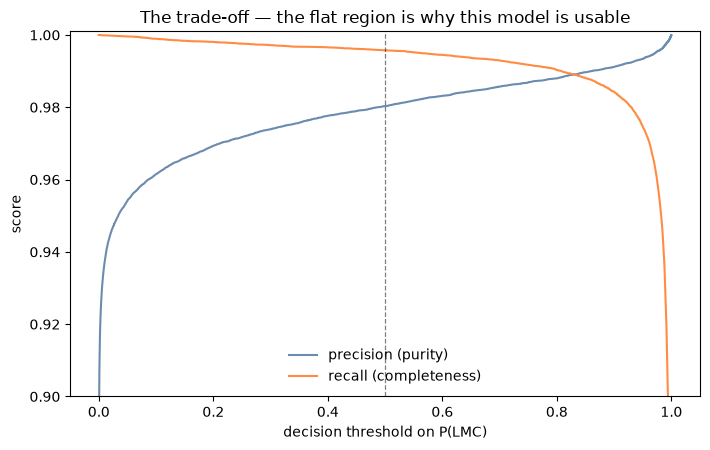

best-F1 threshold: 0.767  ->  precision 0.9873, recall 0.9914
at the default 0.5: precision 0.9804, recall 0.9958


In [14]:
prec, rec, thr = precision_recall_curve(y_te, y_prob)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(thr, prec[:-1], label="precision (purity)", color="#6b8cae")
ax.plot(thr, rec[:-1], label="recall (completeness)", color="#ff8c42")
ax.axvline(0.5, ls="--", lw=0.9, c="k", alpha=0.5)
ax.set_xlabel("decision threshold on P(LMC)"); ax.set_ylabel("score")
ax.set_ylim(0.90, 1.001)
ax.set_title("The trade-off — the flat region is why this model is usable")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
best = int(np.argmax(f1[:-1]))
print(f"best-F1 threshold: {thr[best]:.3f}  ->  precision {prec[best]:.4f}, recall {rec[best]:.4f}")
print(f"at the default 0.5: precision {prec[np.searchsorted(thr, 0.5)]:.4f}, "
      f"recall {rec[np.searchsorted(thr, 0.5)]:.4f}")

## 10. Save

Into `outputs/v1_baseline/` — versioned, because notebook 05 trains a second model and the
comparison between them is the point of this project, not a footnote.

| file | why |
| --- | --- |
| `model.joblib` | the trained model, for notebooks 03/04 and the exporters |
| `feature_cols.json` | the exact feature order — a silently permuted column would score like a bug that isn't one |
| `split.npz` | **the held-out rows plus a hash of the labels they were drawn from**, so a stale split fails loudly |
| `metrics.json` | the numbers above, stamped with the data fingerprint, so the README and the site quote *this* run |

`outputs/MODELS.json` indexes whatever has been trained, so the export scripts and the README
have one place to look rather than each guessing a filename.

In [15]:
joblib.dump(clf, OUT / "model.joblib")
(OUT / "feature_cols.json").write_text(json.dumps(FEATURES, indent=2))
save_split(OUT / "split.npz", train_idx, test_idx, y)

metrics = {
    "name": "v1_baseline",
    "seed": SEED,
    "test_size": TEST_SIZE,
    "data_fingerprint": lmc.fingerprint(),
    "n_rows_clean": int(df.height),
    "n_train": int(len(train_idx)),
    "n_test": int(len(test_idx)),
    "lmc_fraction": round(float(y.mean()), 4),
    "scale_pos_weight": round(float(spw), 4),
    "roc_auc": round(float(roc), 4),
    "pr_auc": round(float(pr), 4),
    "threshold": 0.5,
    "confusion": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    "recall_lmc": round(float(tp / (tp + fn)), 4),
    "purity_lmc": round(float(tp / (tp + fp)), 4),
    "contamination_rate": round(float(fp / (fp + tn)), 4),
    "features": FEATURES,
    "excluded_features": EXCLUDED,
    "importance": {f: round(float(v), 5) for f, v in zip(FEATURES, imp)},
    "hyperparameters": {k: clf.get_params()[k] for k in
                        ("n_estimators", "max_depth", "learning_rate",
                         "subsample", "colsample_bytree")},
}
(OUT / "metrics.json").write_text(json.dumps(metrics, indent=2))

# The registry every downstream consumer reads instead of guessing a path.
REG = Path("../outputs/MODELS.json")
registry = json.loads(REG.read_text()) if REG.exists() else {}
registry["v1_baseline"] = {
    "dir": "outputs/v1_baseline",
    "notebook": "02-baseline_model.ipynb",
    "features": FEATURES,
    "headline": {"roc_auc": round(float(roc), 4), "pr_auc": round(float(pr), 4),
                 "recall_lmc": round(float(tp / (tp + fn)), 4),
                 "purity_lmc": round(float(tp / (tp + fp)), 4)},
    "note": "Simulated data only. Real-sky transfer is measured in notebook 03.",
}
REG.write_text(json.dumps(registry, indent=2))

for f in ("model.joblib", "feature_cols.json", "split.npz", "metrics.json"):
    print(f"saved  {(OUT / f)}   ({(OUT / f).stat().st_size / 1024:.1f} KB)")
print(f"saved  {REG}")

saved  ../outputs/v1_baseline/model.joblib   (1385.9 KB)
saved  ../outputs/v1_baseline/feature_cols.json   (0.2 KB)
saved  ../outputs/v1_baseline/split.npz   (793.2 KB)
saved  ../outputs/v1_baseline/metrics.json   (1.7 KB)
saved  ../outputs/MODELS.json


## Summary

- Trained XGBoost on **physical features only** — motion, distance, photometry, and
  measurement quality — with sky position deliberately withheld.
- Handled the 3.58 : 1 imbalance with `scale_pos_weight` and reported **recall and purity**
  rather than accuracy, which is 78% for free.
- **Proper motion carries the model**, and parallax barely registers — the same conclusion
  notebook 01 reached by eye, arrived at independently by the trees.
- **Demonstrated** the position exclusion instead of asserting it. A model given only `ra`
  and `dec` matches the physics model's recall — and turns out to have learned a rectangle:
  100% of LMC rows in this file lie inside one box in RA/Dec, an artifact of the simulation's
  sampling window rather than a fact about the galaxy. Its catalogue is 79.6% pure overall
  and 64% pure in the outskirts.
- Saved the model, the feature order, the held-out indices, and the metrics.

**Next — notebook 03: the real-sky test.** Everything so far is trained and scored on *simulated*
data (the Gaia Object Generator). Notebook 03 runs this model on 4,485 Cepheids and 22,006
RR Lyrae — real Gaia observations of stars confirmed as LMC members by an independent method.
A model that learned physics should tag them; a model that learned the simulation should not.